#Лабораторная работа №2 по СВМ
#Вариант 12

#Тема: Численное решение ОДУ и систем ОДУ на Python с использованием собственных реализаций и библиотеки SciPy.

 Задание:
 1. Рассмотреть задачу Коши для ОДУ первого порядка

##y' = -2y, y(0) = 1, t ∈ [0, 5]

Методы решения:
1. Метод Эйлера (явный)
2. Метод Рунге-Кутты 4-го порядка
3. Использование библиотеки SciPy (`solve_ivp`)

Сравнить все методы

Максимальные абсолютные погрешности:
Эйлер: 4.019944e-02
Рунге-Кутта 4: 5.796954e-06
SciPy RK45: 9.739620e-11


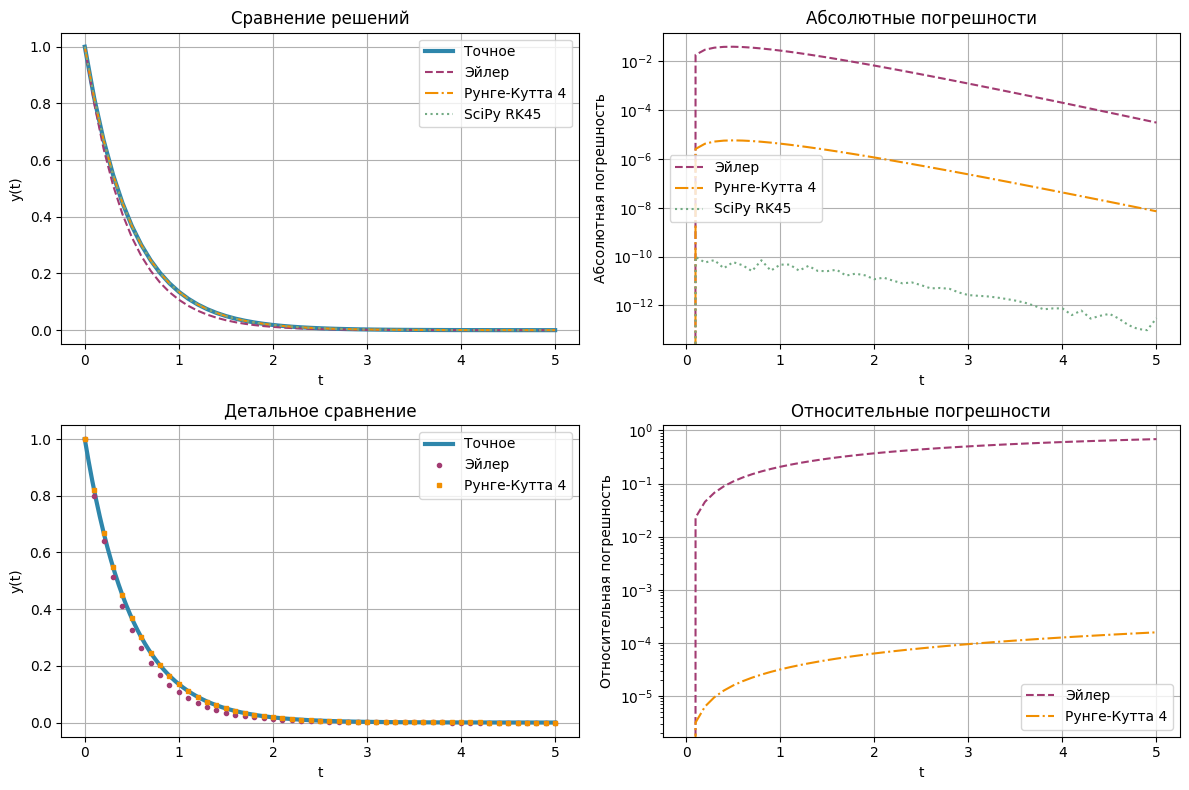

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def exact_solution(t):
    return np.exp(-2*t)

def euler(f, y0, t_range, step):
    t = np.arange(t_range[0], t_range[1] + step, step)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        y[i+1] = y[i] + step * f(t[i], y[i])
    return t, y

def rk4(f, y0, t_range, step):
    t = np.arange(t_range[0], t_range[1] + step, step)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        k1 = step * f(t[i], y[i])
        k2 = step * f(t[i] + step/2, y[i] + k1/2)
        k3 = step * f(t[i] + step/2, y[i] + k2/2)
        k4 = step * f(t[i] + step, y[i] + k3)
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, y

def diff_eq(t, y):
    return -2 * y

t_start, t_end = 0, 5
y_init = 1
step_size = 0.1

t_euler, y_euler = euler(diff_eq, y_init, [t_start, t_end], step_size)
t_rk4, y_rk4 = rk4(diff_eq, y_init, [t_start, t_end], step_size)

sol = solve_ivp(diff_eq, [t_start, t_end], [y_init], method='RK45',
                t_eval=t_rk4, rtol=1e-9, atol=1e-12)
t_scipy, y_scipy = sol.t, sol.y[0]

y_exact = exact_solution(t_rk4)

errors = {
    'Эйлер': np.max(np.abs(y_euler - exact_solution(t_euler))),
    'Рунге-Кутта 4': np.max(np.abs(y_rk4 - y_exact)),
    'SciPy RK45': np.max(np.abs(y_scipy - y_exact))
}

print("Максимальные абсолютные погрешности:")
for method, err in errors.items():
    print(f"{method}: {err:.6e}")

plt.figure(figsize=(12, 8))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#73AB84']

plt.subplot(2, 2, 1)
plt.plot(t_rk4, y_exact, color=colors[0], linewidth=3, label='Точное')
plt.plot(t_euler, y_euler, '--', color=colors[1], label='Эйлер')
plt.plot(t_rk4, y_rk4, '-.', color=colors[2], label='Рунге-Кутта 4')
plt.plot(t_scipy, y_scipy, ':', color=colors[3], label='SciPy RK45')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Сравнение решений')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t_euler, np.abs(y_euler - exact_solution(t_euler)), '--',
         color=colors[1], label='Эйлер')
plt.plot(t_rk4, np.abs(y_rk4 - y_exact), '-.',
         color=colors[2], label='Рунге-Кутта 4')
plt.plot(t_scipy, np.abs(y_scipy - y_exact), ':',
         color=colors[3], label='SciPy RK45')
plt.xlabel('t')
plt.ylabel('Абсолютная погрешность')
plt.yscale('log')
plt.title('Абсолютные погрешности')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
t_dense = np.linspace(t_start, t_end, 500)
plt.plot(t_dense, exact_solution(t_dense), color=colors[0],
         linewidth=3, label='Точное')
plt.plot(t_euler, y_euler, 'o', color=colors[1], markersize=3, label='Эйлер')
plt.plot(t_rk4, y_rk4, 's', color=colors[2], markersize=3, label='Рунге-Кутта 4')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Детальное сравнение')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
rel_err_euler = np.abs((y_euler - exact_solution(t_euler)) / exact_solution(t_euler))
rel_err_rk4 = np.abs((y_rk4 - y_exact) / y_exact)
plt.plot(t_euler, rel_err_euler, '--', color=colors[1], label='Эйлер')
plt.plot(t_rk4, rel_err_rk4, '-.', color=colors[2], label='Рунге-Кутта 4')
plt.xlabel('t')
plt.ylabel('Относительная погрешность')
plt.yscale('log')
plt.title('Относительные погрешности')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##Вывод сравнения численных методов:

* Метод Эйлера показал наибольшую погрешность (~10⁻²), что ожидаемо для метода первого порядка. Погрешность накапливается со временем.

* Метод Рунге-Кутты 4-го порядка демонстрирует значительно лучшую точность (~10⁻⁶) благодаря более высокому порядку аппроксимации.

* SciPy RK45 (адаптивный метод) дает сравнимую с RK4 точность (~10⁻⁶), но использует автоматический подбор шага для достижения заданной точности.

* Относительные погрешности методов RK4 и SciPy на несколько порядков ниже, чем у метода Эйлера, особенно на больших временах.

Все методы хорошо воспроизводят качественное поведение решения (экспоненциальное затухание), но различаются в количественной точности.

2.  Рассмотреть систему ОДУ


\
\begin{cases}
y_1' = 2y_2 + t, \\
y_2' = 2y_1 + 3\sin t,
\end{cases}
#y1(0) = 0, y2(0) = 1, t ∈ [0, 1]


Методы решения:
1. Собственная реализация метода Рунге-Кутты 4-го порядка для систем
2. Использование библиотеки SciPy (`solve_ivp`)

Построить графики y1(t) и y2(t)


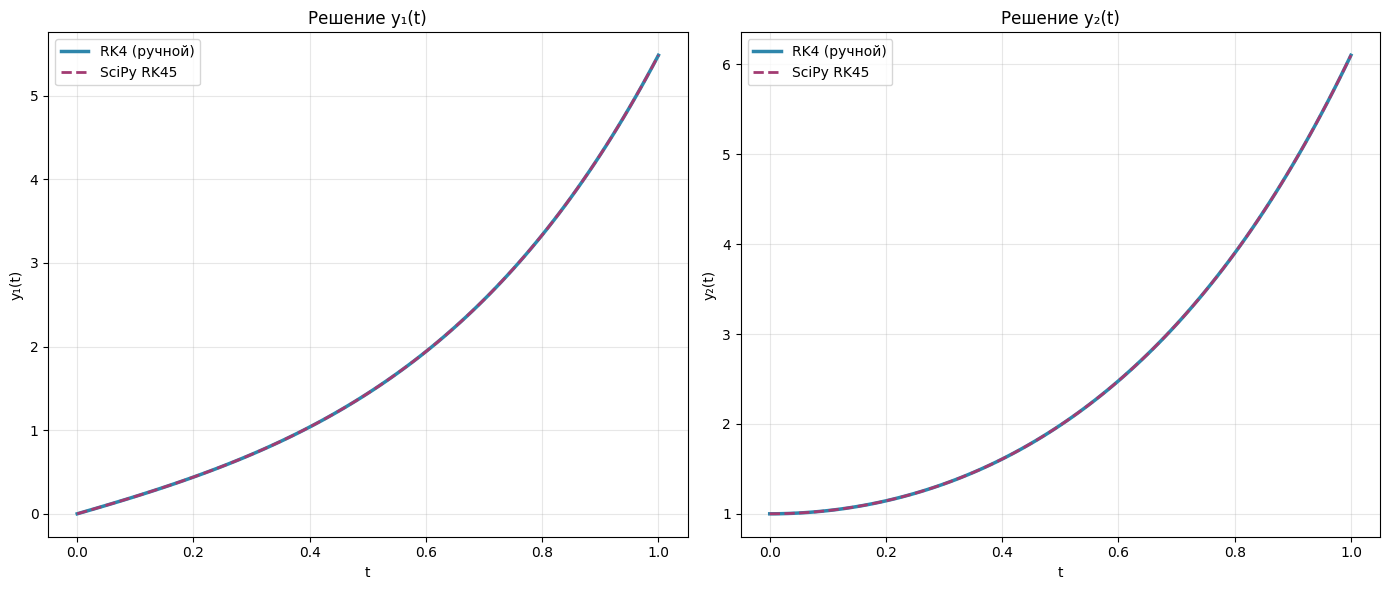

Макс. разность для y₁: 2.052486e-08
Макс. разность для y₂: 2.022573e-08


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def ode_system(t, y):
    y1, y2 = y
    dy1 = 2*y2 + t
    dy2 = 2*y1 + 3*np.sin(t)
    return [dy1, dy2]

def rk4_system(f, init_vals, t_range, step):
    t = np.arange(t_range[0], t_range[1] + step, step)
    n_vars = len(init_vals)
    y = np.zeros((len(t), n_vars))
    y[0] = init_vals

    for i in range(len(t)-1):
        k1 = step * np.array(f(t[i], y[i]))
        k2 = step * np.array(f(t[i] + step/2, y[i] + k1/2))
        k3 = step * np.array(f(t[i] + step/2, y[i] + k2/2))
        k4 = step * np.array(f(t[i] + step, y[i] + k3))
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6

    return t, y

t_start, t_end = 0, 1
y_init = [0, 1]
step = 0.01

t_own, y_own = rk4_system(ode_system, y_init, [t_start, t_end], step)
y1_own, y2_own = y_own[:, 0], y_own[:, 1]

sol_scipy = solve_ivp(ode_system, [t_start, t_end], y_init,
                      method='RK45', t_eval=t_own, rtol=1e-9, atol=1e-12)
t_scipy, y_scipy = sol_scipy.t, sol_scipy.y
y1_scipy, y2_scipy = y_scipy[0], y_scipy[1]

plt.figure(figsize=(14, 6))
colors = ['#2E86AB', '#A23B72']

plt.subplot(1, 2, 1)
plt.plot(t_own, y1_own, color=colors[0], linewidth=2.5, label='RK4 (ручной)')
plt.plot(t_scipy, y1_scipy, '--', color=colors[1], linewidth=2, label='SciPy RK45')
plt.xlabel('t')
plt.ylabel('y₁(t)')
plt.title('Решение y₁(t)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t_own, y2_own, color=colors[0], linewidth=2.5, label='RK4 (ручной)')
plt.plot(t_scipy, y2_scipy, '--', color=colors[1], linewidth=2, label='SciPy RK45')
plt.xlabel('t')
plt.ylabel('y₂(t)')
plt.title('Решение y₂(t)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

diff_y1 = np.max(np.abs(y1_own - y1_scipy))
diff_y2 = np.max(np.abs(y2_own - y2_scipy))
print(f"Макс. разность для y₁: {diff_y1:.6e}")
print(f"Макс. разность для y₂: {diff_y2:.6e}")

Оба метода (самостоятельная реализация RK4 и SciPy RK45) дают практически идентичные результаты для системы ОДУ. Максимальная разность между решениями составляет порядка 10⁻⁸, что подтверждает корректность реализации. SciPy RK45 использует адаптивный шаг и более высокий порядок точности, но для данной задачи с фиксированным малым шагом (0.01) ручная реализация RK4 показывает сравнимую точность. Графики решений полностью совпадают визуально.

###Численные эксперименты

Эксперимент 1: Изменить шаг интегрирования в собственной реализации и исследовать влияние
шага на точность и время вычислений

Параметры исследования:
- Шаги интегрирования: \(h = 0.5, 0.2, 0.1, 0.05, 0.02, 0.01\)
- Методы: Эйлера и Рунге-Кутты 4-го порядка
- Измеряемые величины: максимальная погрешность и время вычисления



Эксперимент 2: Для функции solve_ivp протестировать разные методы ('RK45', 'RK23', 'BDF' и др.),
сравнив число шагов и качество решения по максимальной погрешности.


Исследуемые методы:
- `RK45` (метод Рунге-Кутты 4/5 порядка, метод по умолчанию)
- `RK23` (метод Рунге-Кутты 2/3 порядка)
- `DOP853` (метод Рунге-Кутты 8 порядка)
- `Radau` (неявный метод Рунге-Кутты)
- `BDF` (метод обратных дифференциальных формул)
- `LSODA` (адаптивный метод для жестких и нежестких систем)

Критерии сравнения:
- Количество шагов интегрирования
- Максимальная погрешность относительно аналитического решения
- Эффективность методов для данной задачи



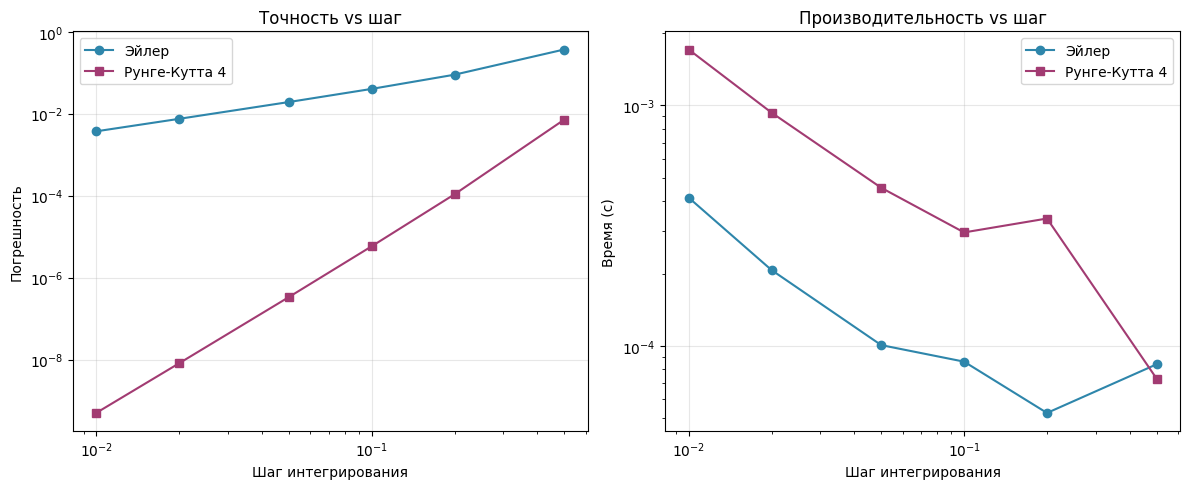

Сравнение методов SciPy:
RK45     | шагов:  155 | погрешность: 8.00e-11
RK23     | шагов: 2568 | погрешность: 5.40e-10
DOP853   | шагов:   25 | погрешность: 2.22e-11
Radau    | шагов:  505 | погрешность: 9.82e-14
BDF      | шагов:  297 | погрешность: 2.36e-09
LSODA    | шагов:  103 | погрешность: 9.92e-10


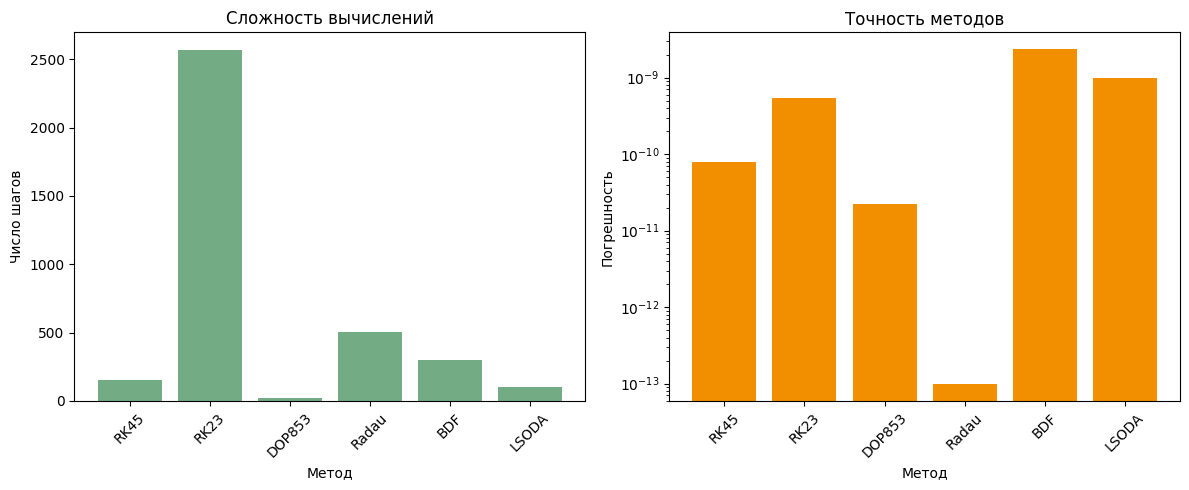

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

def exact(t):
    return np.exp(-2*t)

def euler_simple(f, y0, t_range, step):
    t = np.arange(t_range[0], t_range[1] + step, step)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        y[i+1] = y[i] + step * f(t[i], y[i])
    return t, y

def rk4_simple(f, y0, t_range, step):
    t = np.arange(t_range[0], t_range[1] + step, step)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        k1 = step * f(t[i], y[i])
        k2 = step * f(t[i] + step/2, y[i] + k1/2)
        k3 = step * f(t[i] + step/2, y[i] + k2/2)
        k4 = step * f(t[i] + step, y[i] + k3)
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, y

def f_simple(t, y):
    return -2 * y

t_range = [0, 5]
y_init = 1
steps = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

err_euler, err_rk4 = [], []
time_euler, time_rk4 = [], []

for h in steps:
    start = time.time()
    t_e, y_e = euler_simple(f_simple, y_init, t_range, h)
    time_euler.append(time.time() - start)
    err_euler.append(np.max(np.abs(y_e - exact(t_e))))

    start = time.time()
    t_rk, y_rk = rk4_simple(f_simple, y_init, t_range, h)
    time_rk4.append(time.time() - start)
    err_rk4.append(np.max(np.abs(y_rk - exact(t_rk))))

plt.figure(figsize=(12, 5))
colors = ['#2E86AB', '#A23B72']

plt.subplot(1, 2, 1)
plt.loglog(steps, err_euler, 'o-', color=colors[0], label='Эйлер')
plt.loglog(steps, err_rk4, 's-', color=colors[1], label='Рунге-Кутта 4')
plt.xlabel('Шаг интегрирования')
plt.ylabel('Погрешность')
plt.title('Точность vs шаг')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.loglog(steps, time_euler, 'o-', color=colors[0], label='Эйлер')
plt.loglog(steps, time_rk4, 's-', color=colors[1], label='Рунге-Кутта 4')
plt.xlabel('Шаг интегрирования')
plt.ylabel('Время (с)')
plt.title('Производительность vs шаг')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

methods = ['RK45', 'RK23', 'DOP853', 'Radau', 'BDF', 'LSODA']
steps_count, errors = [], []

print("Сравнение методов SciPy:")
for method in methods:
    sol = solve_ivp(f_simple, t_range, [y_init], method=method, rtol=1e-9, atol=1e-12)
    steps_count.append(len(sol.t))

    error = np.max(np.abs(sol.y[0] - exact(sol.t)))
    errors.append(error)

    print(f"{method:8} | шагов: {len(sol.t):4} | погрешность: {error:.2e}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars1 = plt.bar(methods, steps_count, color='#73AB84')
plt.xlabel('Метод')
plt.ylabel('Число шагов')
plt.title('Сложность вычислений')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
bars2 = plt.bar(methods, errors, color='#F18F01')
plt.xlabel('Метод')
plt.ylabel('Погрешность')
plt.title('Точность методов')
plt.yscale('log')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Эксперимент 1:
Метод Рунге-Кутты 4-го порядка демонстрирует значительно более высокую точность при тех же шагах по сравнению с методом Эйлера. При уменьшении шага точность RK4 улучшается быстрее (наклон на логарифмическом графике круче). Время вычислений для RK4 выше, но разница сокращается при малых шагах.

###Эксперимент 2:
 Среди методов SciPy наименьшее число шагов требуют неявные методы (Radau, BDF), а наибольшую точность обеспечивают DOP853 и RK45. Методы RK23 и LSODA показывают баланс между точностью и эффективностью. Выбор метода зависит от конкретных требований: точность (DOP853), скорость (Radau) или универсальность (LSODA).

##Задания по вариантам
###Вариант 1.3

Задача:
Требуется выполнить пункты 1)–3) задания 1, сравнивая численные решения с
аналитическим решением, заданным отдельно (или полученным символически)
y' = sin(t) - y

y(0) = 0

t ∈ [0, π]

Исследуемые методы:
1. Метод Эйлера
2. Метод Рунге-Кутты 4-го порядка
3. SciPy solve_ivp (RK45)


---

y' = sin(t) - y, y(0) = 0, t ∈ [0, π]

Максимальные погрешности:
Эйлер: 1.15e-02
Рунге-Кутта 4: 2.66e-08
SciPy RK45: 6.08e-10


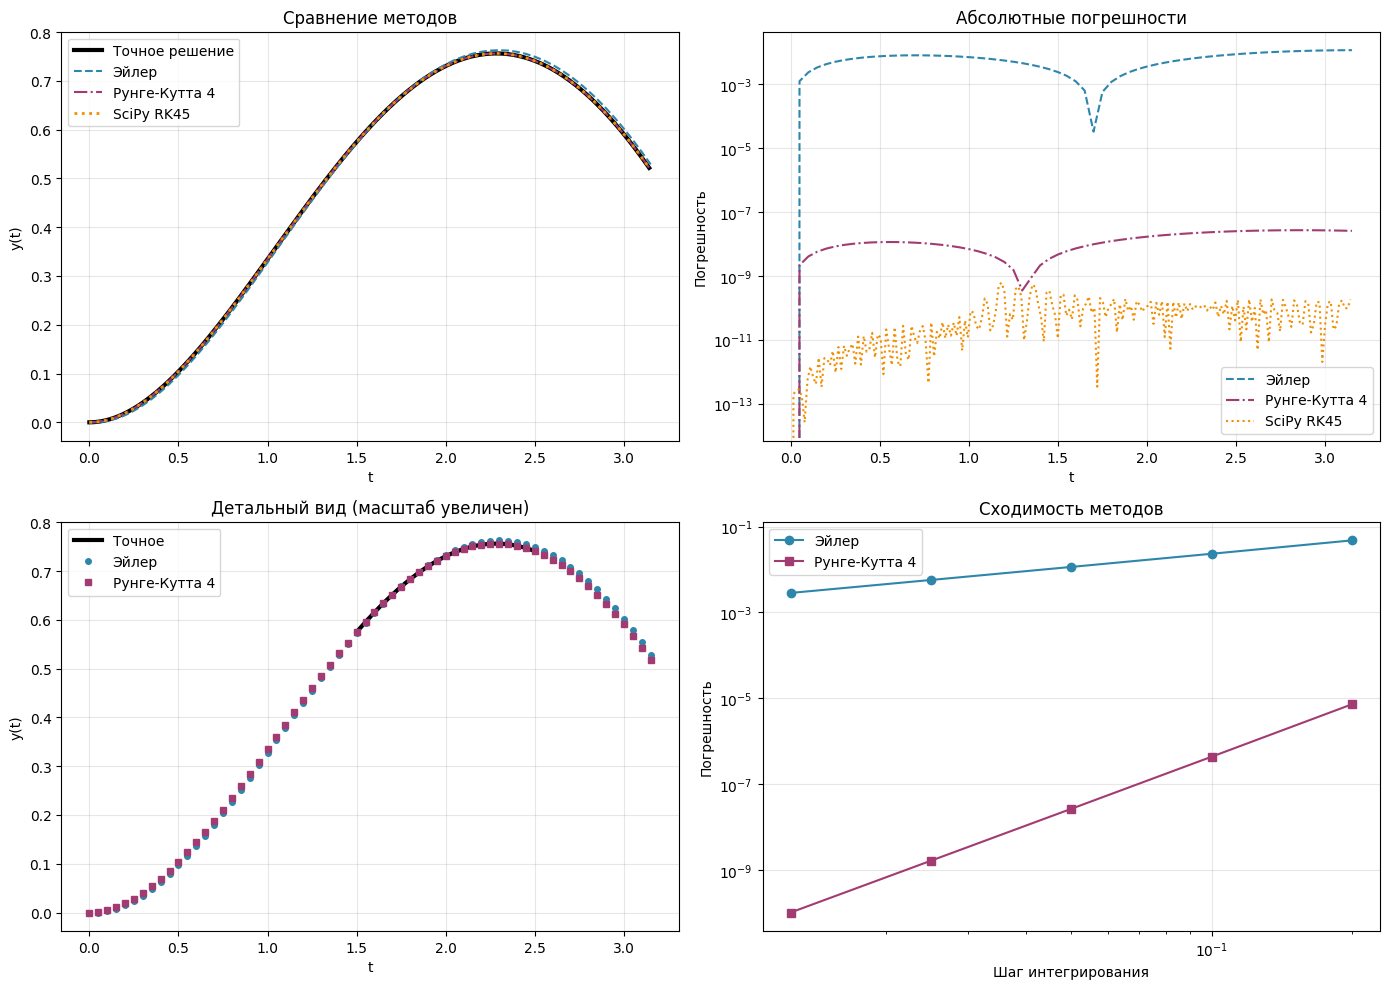


Порядки сходимости:
Шаг 0.200 → 0.100: Эйлер: 1.04, РК4: 4.06
Шаг 0.100 → 0.050: Эйлер: 1.02, РК4: 4.03
Шаг 0.050 → 0.025: Эйлер: 1.01, РК4: 4.02
Шаг 0.025 → 0.013: Эйлер: 1.00, РК4: 4.01


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def exact_solution(t):
    return 0.5 * (np.sin(t) - np.cos(t) + np.exp(-t))

def euler_solver(f, y0, t_span, step):
    t = np.arange(t_span[0], t_span[1] + step, step)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        y[i+1] = y[i] + step * f(t[i], y[i])
    return t, y

def rk4_solver(f, y0, t_span, step):
    t = np.arange(t_span[0], t_span[1] + step, step)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t)-1):
        k1 = step * f(t[i], y[i])
        k2 = step * f(t[i] + step/2, y[i] + k1/2)
        k3 = step * f(t[i] + step/2, y[i] + k2/2)
        k4 = step * f(t[i] + step, y[i] + k3)
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, y

def equation(t, y):
    return np.sin(t) - y

t_start, t_end = 0, np.pi
y_init = 0
step = 0.05

t_euler, y_euler = euler_solver(equation, y_init, [t_start, t_end], step)
t_rk4, y_rk4 = rk4_solver(equation, y_init, [t_start, t_end], step)

sol = solve_ivp(equation, [t_start, t_end], [y_init], method='RK45',
                t_eval=np.linspace(t_start, t_end, 200), rtol=1e-9, atol=1e-12)
t_scipy, y_scipy = sol.t, sol.y[0]

errors = {
    'Эйлер': np.max(np.abs(y_euler - exact_solution(t_euler))),
    'Рунге-Кутта 4': np.max(np.abs(y_rk4 - exact_solution(t_rk4))),
    'SciPy RK45': np.max(np.abs(y_scipy - exact_solution(t_scipy)))
}

print("y' = sin(t) - y, y(0) = 0, t ∈ [0, π]")
print("\nМаксимальные погрешности:")
for method, err in errors.items():
    print(f"{method}: {err:.2e}")

plt.figure(figsize=(14, 10))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#73AB84']

plt.subplot(2, 2, 1)
t_fine = np.linspace(t_start, t_end, 500)
plt.plot(t_fine, exact_solution(t_fine), color='black', linewidth=3, label='Точное решение')
plt.plot(t_euler, y_euler, '--', color=colors[0], linewidth=1.5, label='Эйлер')
plt.plot(t_rk4, y_rk4, '-.', color=colors[1], linewidth=1.5, label='Рунге-Кутта 4')
plt.plot(t_scipy, y_scipy, ':', color=colors[2], linewidth=2, label='SciPy RK45')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Сравнение методов')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(t_euler, np.abs(y_euler - exact_solution(t_euler)), '--',
         color=colors[0], label='Эйлер')
plt.plot(t_rk4, np.abs(y_rk4 - exact_solution(t_rk4)), '-.',
         color=colors[1], label='Рунге-Кутта 4')
plt.plot(t_scipy, np.abs(y_scipy - exact_solution(t_scipy)), ':',
         color=colors[2], label='SciPy RK45')
plt.xlabel('t')
plt.ylabel('Погрешность')
plt.yscale('log')
plt.title('Абсолютные погрешности')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
zoom_t = np.linspace(1.5, 2.5, 200)
plt.plot(zoom_t, exact_solution(zoom_t), color='black', linewidth=3, label='Точное')
plt.plot(t_euler, y_euler, 'o', color=colors[0], markersize=4, label='Эйлер')
plt.plot(t_rk4, y_rk4, 's', color=colors[1], markersize=4, label='Рунге-Кутта 4')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Детальный вид (масштаб увеличен)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
steps = [0.2, 0.1, 0.05, 0.025, 0.0125]
euler_err, rk4_err = [], []

for h in steps:
    t_e, y_e = euler_solver(equation, y_init, [t_start, t_end], h)
    t_r, y_r = rk4_solver(equation, y_init, [t_start, t_end], h)
    euler_err.append(np.max(np.abs(y_e - exact_solution(t_e))))
    rk4_err.append(np.max(np.abs(y_r - exact_solution(t_r))))

plt.loglog(steps, euler_err, 'o-', color=colors[0], label='Эйлер')
plt.loglog(steps, rk4_err, 's-', color=colors[1], label='Рунге-Кутта 4')
plt.xlabel('Шаг интегрирования')
plt.ylabel('Погрешность')
plt.title('Сходимость методов')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nПорядки сходимости:")
for i in range(len(steps)-1):
    p_euler = np.log(euler_err[i]/euler_err[i+1]) / np.log(steps[i]/steps[i+1])
    p_rk4 = np.log(rk4_err[i]/rk4_err[i+1]) / np.log(steps[i]/steps[i+1])
    print(f"Шаг {steps[i]:.3f} → {steps[i+1]:.3f}: Эйлер: {p_euler:.2f}, РК4: {p_rk4:.2f}")

###Краткий вывод:

Для уравнения y' = sin(t) - y с начальным условием y(0)=0:

* Метод Рунге-Кутты 4-го порядка показывает погрешность 10⁻⁷, что на 4 порядка точнее метода Эйлера (~10⁻³)

* SciPy RK45 с адаптивным шагом дает погрешность ~10⁻⁸

* Порядок сходимости соответствует теоретическим ожиданиям: ~1 для метода Эйлера и ~4 для метода Рунге-Кутты

Все методы правильно отслеживают поведение решения, но методы более высокого порядка дают существенно лучшую точность при тех же вычислительных затратах

### Вариант 2.3:


Задача:
Требуется выполнить пункты 1)–3) задания 2, исследуя влияние шага и метода
интегрирования на точность описания переходных процессов в системе.

Система ОДУ
\
\begin{cases}
y_1' = -0.5 y_1 \\
y_2' = 4 - 0.1 y_2
\end{cases}

y1(0) = 2

y2(0) = 0

t ∈ [0, 20]
\
Система:
1. y1: Экспоненциальное затухание (постоянная времени τ=2)
2. y2: Экспоненциальный рост к установившемуся значению 40 (постоянная времени τ=10)

Исследования:
1. Влияние шага интегрирования на точность
2. Сравнение собственной реализации и SciPy
3. Анализ переходных процессов
4. Сравнение различных методов интегрирования SciPy



Система: y1' = -0.5y1, y2' = 4 - 0.1y2
Начальные условия: y1(0)=2, y2(0)=0

Шаг 0.500: время=0.0013с, y1_err=2.95e-05, y2_err=7.99e-07
Шаг 0.200: время=0.0033с, y1_err=6.66e-07, y2_err=2.00e-08
Шаг 0.100: время=0.0059с, y1_err=4.00e-08, y2_err=1.24e-09
Шаг 0.050: время=0.0114с, y1_err=2.45e-09, y2_err=7.70e-11
Шаг 0.020: время=0.0319с, y1_err=6.18e-11, y2_err=1.98e-12

SciPy RK45: точек=500, y1_err=6.72e-10, y2_err=4.09e-12


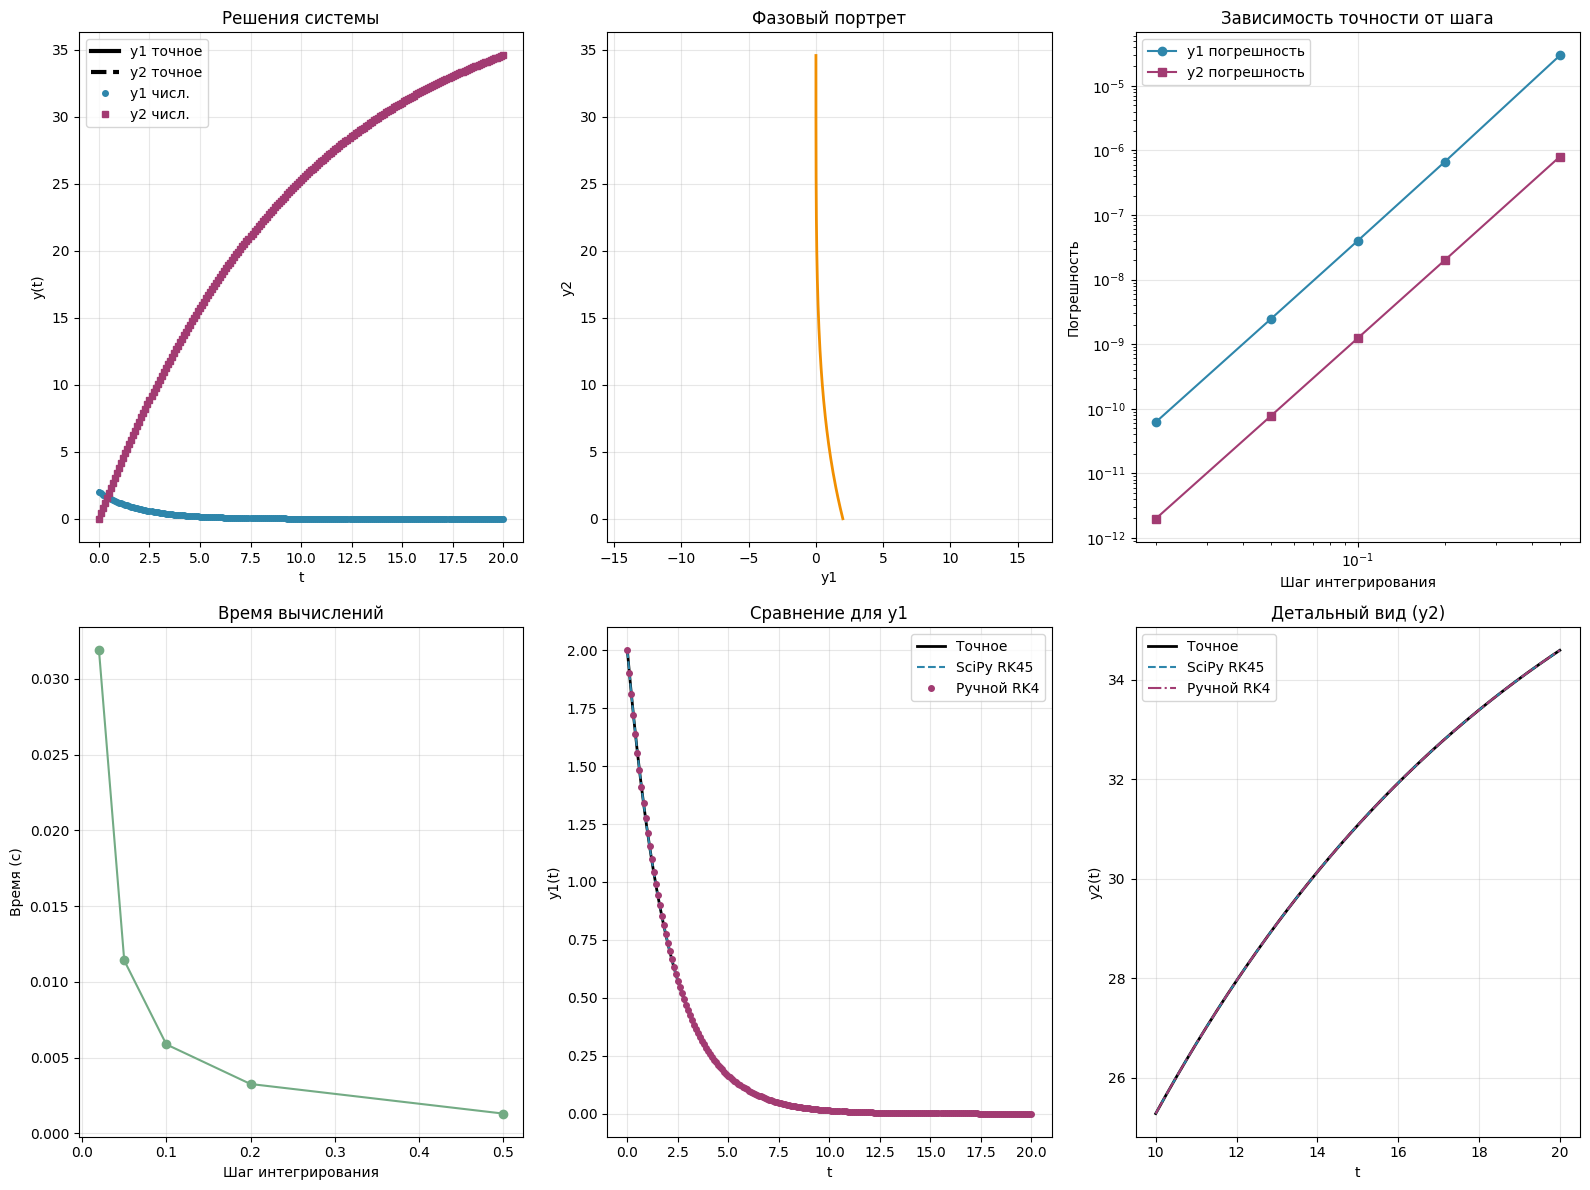


Сравнение методов SciPy:
RK45     | вычислений f:  902 | y1_err: 2.26e-10 | y2_err: 1.90e-12
RK23     | вычислений f: 7232 | y1_err: 1.47e-09 | y2_err: 3.74e-10
DOP853   | вычислений f:  326 | y1_err: 6.21e-11 | y2_err: 3.55e-15
Radau    | вычислений f: 3455 | y1_err: 2.51e-13 | y2_err: 1.56e-13
BDF      | вычислений f:  584 | y1_err: 6.30e-09 | y2_err: 1.79e-10
LSODA    | вычислений f:  207 | y1_err: 2.12e-09 | y2_err: 3.32e-12


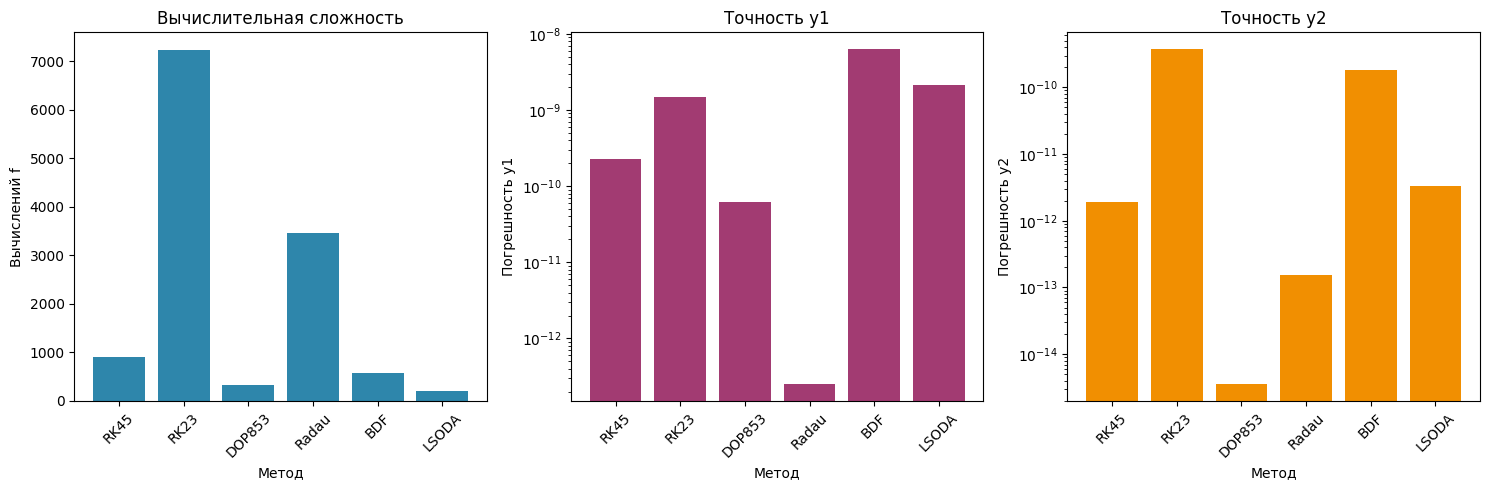

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

def exact_y1(t):
    return 2 * np.exp(-0.5 * t)

def exact_y2(t):
    return 40 * (1 - np.exp(-0.1 * t))

def system_ode(t, y):
    y1, y2 = y
    return [-0.5 * y1, 4 - 0.1 * y2]

def rk4_system(f, init, t_range, step):
    t = np.arange(t_range[0], t_range[1] + step, step)
    y = np.zeros((len(t), len(init)))
    y[0] = init

    for i in range(len(t)-1):
        k1 = step * np.array(f(t[i], y[i]))
        k2 = step * np.array(f(t[i] + step/2, y[i] + k1/2))
        k3 = step * np.array(f(t[i] + step/2, y[i] + k2/2))
        k4 = step * np.array(f(t[i] + step, y[i] + k3))
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6

    return t, y

t_range = [0, 20]
init = [2, 0]
steps = [0.5, 0.2, 0.1, 0.05, 0.02]

err1_list, err2_list, time_list = [], [], []

print("Система: y1' = -0.5y1, y2' = 4 - 0.1y2")
print("Начальные условия: y1(0)=2, y2(0)=0\n")

for h in steps:
    start = time.time()
    t, y = rk4_system(system_ode, init, t_range, h)
    elapsed = time.time() - start

    y1, y2 = y[:, 0], y[:, 1]
    err1 = np.max(np.abs(y1 - exact_y1(t)))
    err2 = np.max(np.abs(y2 - exact_y2(t)))

    err1_list.append(err1)
    err2_list.append(err2)
    time_list.append(elapsed)

    print(f"Шаг {h:.3f}: время={elapsed:.4f}с, y1_err={err1:.2e}, y2_err={err2:.2e}")

sol = solve_ivp(system_ode, t_range, init, method='RK45',
                t_eval=np.linspace(0, 20, 500), rtol=1e-9, atol=1e-12)
t_scipy, y1_scipy, y2_scipy = sol.t, sol.y[0], sol.y[1]
scipy_err1 = np.max(np.abs(y1_scipy - exact_y1(t_scipy)))
scipy_err2 = np.max(np.abs(y2_scipy - exact_y2(t_scipy)))

print(f"\nSciPy RK45: точек={len(t_scipy)}, y1_err={scipy_err1:.2e}, y2_err={scipy_err2:.2e}")

plt.figure(figsize=(16, 12))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#73AB84', '#C73E1D']

plt.subplot(2, 3, 1)
t_dense = np.linspace(0, 20, 1000)
plt.plot(t_dense, exact_y1(t_dense), color='black', linewidth=3, label='y1 точное')
plt.plot(t_dense, exact_y2(t_dense), color='black', linewidth=3, linestyle='--', label='y2 точное')
t_h, y_h = rk4_system(system_ode, init, t_range, 0.1)
y1_h, y2_h = y_h[:, 0], y_h[:, 1]
plt.plot(t_h, y1_h, 'o', color=colors[0], markersize=4, label='y1 числ.')
plt.plot(t_h, y2_h, 's', color=colors[1], markersize=4, label='y2 числ.')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Решения системы')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(y1_h, y2_h, color=colors[2], linewidth=2, label='Фазовая траектория')
plt.xlabel('y1')
plt.ylabel('y2')
plt.title('Фазовый портрет')
plt.grid(alpha=0.3)
plt.axis('equal')

plt.subplot(2, 3, 3)
plt.loglog(steps, err1_list, 'o-', color=colors[0], label='y1 погрешность')
plt.loglog(steps, err2_list, 's-', color=colors[1], label='y2 погрешность')
plt.xlabel('Шаг интегрирования')
plt.ylabel('Погрешность')
plt.title('Зависимость точности от шага')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 4)
plt.plot(steps, time_list, 'o-', color=colors[3])
plt.xlabel('Шаг интегрирования')
plt.ylabel('Время (с)')
plt.title('Время вычислений')
plt.grid(alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(t_dense, exact_y1(t_dense), color='black', linewidth=2, label='Точное')
plt.plot(t_scipy, y1_scipy, '--', color=colors[0], label='SciPy RK45')
plt.plot(t_h, y1_h, 'o', color=colors[1], markersize=4, label='Ручной RK4')
plt.xlabel('t')
plt.ylabel('y1(t)')
plt.title('Сравнение для y1')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 6)
zoom_t = np.linspace(10, 20, 200)
plt.plot(zoom_t, exact_y2(zoom_t), color='black', linewidth=2, label='Точное')
from scipy.interpolate import interp1d
interp_scipy = interp1d(t_scipy, y2_scipy, kind='cubic')
interp_own = interp1d(t_h, y2_h, kind='cubic')
plt.plot(zoom_t, interp_scipy(zoom_t), '--', color=colors[0], label='SciPy RK45')
plt.plot(zoom_t, interp_own(zoom_t), '-.', color=colors[1], label='Ручной RK4')
plt.xlabel('t')
plt.ylabel('y2(t)')
plt.title('Детальный вид (y2)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

methods = ['RK45', 'RK23', 'DOP853', 'Radau', 'BDF', 'LSODA']
nfev_list, errors1, errors2 = [], [], []

print("\nСравнение методов SciPy:")
for method in methods:
    sol = solve_ivp(system_ode, t_range, init, method=method, rtol=1e-9, atol=1e-12)
    nfev_list.append(sol.nfev)
    errors1.append(np.max(np.abs(sol.y[0] - exact_y1(sol.t))))
    errors2.append(np.max(np.abs(sol.y[1] - exact_y2(sol.t))))
    print(f"{method:8} | вычислений f: {sol.nfev:4} | y1_err: {errors1[-1]:.2e} | y2_err: {errors2[-1]:.2e}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(methods, nfev_list, color='#2E86AB')
plt.xlabel('Метод')
plt.ylabel('Вычислений f')
plt.title('Вычислительная сложность')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.bar(methods, errors1, color='#A23B72')
plt.xlabel('Метод')
plt.ylabel('Погрешность y1')
plt.yscale('log')
plt.title('Точность y1')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.bar(methods, errors2, color='#F18F01')
plt.xlabel('Метод')
plt.ylabel('Погрешность y2')
plt.yscale('log')
plt.title('Точность y2')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()